<a href="https://colab.research.google.com/github/singhprinceraj2210/models/blob/main/cnn_word2vec_sentimental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
nltk.download('stopwords')

!pip install gensim
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df = pd.read_csv("/content/IMDB Dataset.csv")  # columns: text, label

print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return words  # important: return token list

df['tokens'] = df['review'].apply(clean_text)

In [ ]:
w2v_model = Word2Vec(
    sentences=df['tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [ ]:
model_path = "/content/drive/MyDrive/word2vec_model.model"

w2v_model.save(model_path)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
def vectorize_text(tokens, model):
    vector = []
    for word in tokens:
        if word in model.wv:
            vector.append(model.wv[word])
    return vector

df['vector'] = df['tokens'].apply(lambda x: vectorize_text(x, w2v_model))

In [ ]:
MAX_LEN = 100  # adjust based on dataset

X = pad_sequences(
    df['vector'],
    maxlen=MAX_LEN,
    dtype='float32',
    padding='post',
    truncating='post'
)

In [ ]:
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model_cnn = Sequential()

# ✅ FIXED: match Word2Vec shape
model_cnn.add(Input(shape=(100, 100)))   # (MAX_LEN, embedding_dim)

model_cnn.add(Conv1D(64, 5, activation='relu'))
model_cnn.add(MaxPooling1D(pool_size=2))

model_cnn.add(Flatten())

model_cnn.add(Dense(64, activation='relu'))
model_cnn.add(Dropout(0.5))

model_cnn.add(Dense(1, activation='sigmoid'))

model_cnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 96, 64)         │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,801 (893.75 KB)

 Trainable params: 228,801 (893.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(X_train.shape)

(40000, 100, 100)


In [ ]:
Input(shape=(X_train.shape[1], X_train.shape[2]))

<KerasTensor shape=(None, 100, 100), dtype=float32, sparse=False, ragged=False, name=keras_tensor_22>

In [ ]:
history = model_cnn.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.9288 - loss: 0.1700 - val_accuracy: 0.8441 - val_loss: 0.4506
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.9405 - loss: 0.1434 - val_accuracy: 0.8329 - val_loss: 0.5704
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.9498 - loss: 0.1222 - val_accuracy: 0.8413 - val_loss: 0.5425
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.9572 - loss: 0.1045 - val_accuracy: 0.8404 - val_loss: 0.6745
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9610 - loss: 0.0962 - val_accuracy: 0.8356 - val_loss: 0.7356


In [ ]:
loss, accuracy = model_cnn.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8356 - loss: 0.7356
Test Accuracy: 0.8356000185012817


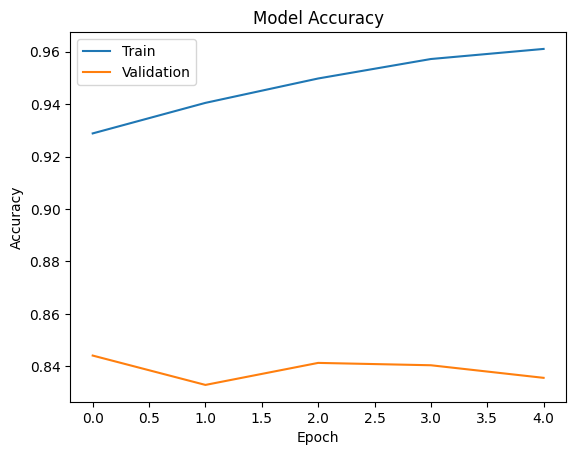

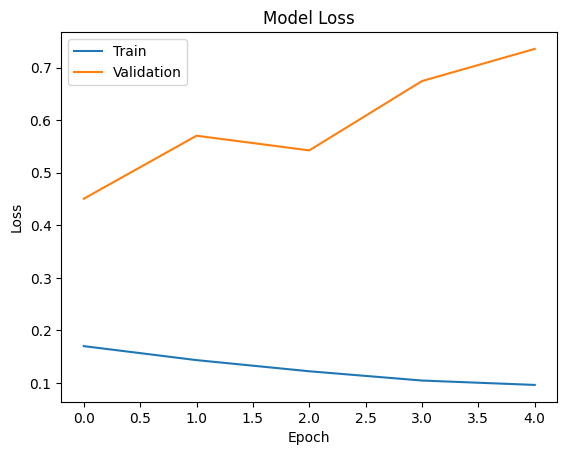

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
y_pred = model_cnn.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[3861 1100]
 [ 544 4495]]
              precision    recall  f1-score   support

           0       0.88      0.78      0.82      4961
           1       0.80      0.89      0.85      5039

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.83     10000
weighted avg       0.84      0.84      0.84     10000



In [ ]:
for i in range(10):
    print("Actual:", y_test[i], "Predicted:", y_pred[i])

Actual: 1 Predicted: [1]
Actual: 1 Predicted: [1]
Actual: 0 Predicted: [0]
Actual: 1 Predicted: [1]
Actual: 0 Predicted: [1]
Actual: 1 Predicted: [1]
Actual: 1 Predicted: [1]
Actual: 1 Predicted: [1]
Actual: 0 Predicted: [0]
Actual: 0 Predicted: [0]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model_cnn.save("/content/drive/MyDrive/updated_cnn_model.keras")

In [ ]:
text="movie is good"

In [ ]:
def predict_sentiment(text):
    # 1. Clean text
    tokens = clean_text(text)

    # 2. Convert to Word2Vec vectors
    vec = []
    for word in tokens:
        if word in w2v_model.wv:
            vec.append(w2v_model.wv[word])

    # 3. Handle empty case (important)
    if len(vec) == 0:
        return "Cannot determine (unknown words)"

    # 4. Padding (same as training)
    vec = pad_sequences([vec], maxlen=100, dtype='float32', padding='post', truncating='post')

    # 5. Prediction
    pred = model_cnn.predict(vec)[0][0]

    # 6. Convert to label
    if pred > 0.5:
        return f"Positive ({pred:.2f})"
    else:
        return f"Negative ({pred:.2f})"

In [ ]:
predict_sentiment("movie is not good")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


'Positive (0.85)'

Twitter dataset


In [ ]:
import pandas as pd
import numpy as np


In [ ]:
# Reduce dataset
tdf = pd.read_csv("/content/Twitter_Data.csv")
# tdf = tdf.sample(50000, random_state=42)

In [ ]:
tdf = tdf[tdf['category'] != 0]
tdf['category'] = tdf['category'].replace(-1, 0)
tdf.dropna(subset=['category'], inplace=True)

tdf['category'] = tdf['category'].astype(int)

In [ ]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33073 entries, 65437 to 64675
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   clean_text  33073 non-null  object
 1   category    33073 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 775.1+ KB


In [ ]:
tdf['category'].value_counts()

,count
category,
1,22138
0,10935


In [ ]:
print(tdf['category'].value_counts())

category
1    22138
0    10935
Name: count, dtype: int64


In [ ]:
tdf['category'] = tdf['category'].replace(-1, 0)

In [ ]:
print(tdf['category'].value_counts())

category
1    22138
0    10935
Name: count, dtype: int64


In [ ]:
tdf.dropna(subset=['category'], inplace=True)
tdf['category'] = tdf['category'].astype(int)

In [ ]:
print(tdf['category'].value_counts())

category
1    22138
0    10935
Name: count, dtype: int64


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

negation_words = {'not', 'no', 'nor', 'never'}

stop_words = stop_words - negation_words
def clean_tweet(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags (keep word)
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [w for w in words if w not in stop_words]

    return words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
tdf['tokens'] = tdf['clean_text'].fillna('').apply(clean_tweet)

In [ ]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33073 entries, 65437 to 64675
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   clean_text  33073 non-null  object
 1   category    33073 non-null  int64 
 2   tokens      33073 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [ ]:
tdf['category'].value_counts()

,count
category,
1,22138
0,10935


In [ ]:
from gensim.models import Word2Vec

w2v_model = Word2Vec.load(
    '/content/drive/MyDrive/word2vec_model.model'
)

print("Word2Vec Loaded Successfully")

Word2Vec Loaded Successfully


In [ ]:
def vectorize_text(tokens, model):
    vector = []
    for word in tokens:
        if word in model.wv:
            vector.append(model.wv[word])
    if len(vector) == 0:
        return [np.zeros(model.vector_size)]
    return vector

X = []
for tokens in tdf['tokens']:
    vec = vectorize_text(tokens, w2v_model)
    X.append(vec)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X = pad_sequences(X, maxlen=100, dtype='float32', padding='post')


In [ ]:
print(X.shape)
print(y_twitter.shape)

(33073, 100, 100)
(33073,)


In [ ]:
y = tdf['category'].astype(int)

In [ ]:
y_twitter = tdf['category'].astype(int)

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/updated_cnn_model.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 96, 64)         │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,604 (1.75 MB)

 Trainable params: 228,801 (893.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 228,803 (893.77 KB)

In [ ]:
predictions = model.predict(X)

1034/1034 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step


In [ ]:
import numpy as np

y_pred = (model.predict(X) > 0.5).astype(int).reshape(-1)

1034/1034 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6126447555407735


In [ ]:
loss, accuracy = model_cnn.evaluate(X, y_twitter)
print("Twitter Dataset Accuracy:", accuracy)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y, y_pred))
print(confusion_matrix(y, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.66      0.79      3550

    accuracy                           0.66      3550
   macro avg       0.50      0.33      0.40      3550
weighted avg       1.00      0.66      0.79      3550

[[   0    0]
 [1218 2332]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
